# Electric Vehicle Adoption Trends & Growth Prediction

## Overview

In this project, I have analyzed an electric vehicle population dataset to understand the trends in adoption across regions, manufacturers, and vehicle types. I have used an regression model to predict the future EV growth

## Objectives

- Analyze EV adoption trends  
- Identify top manufacturers and regions  
- Understand EV type distribution  
- Predict future EV growth

## Problem Statement
People switching over the electric vehicles (EV) has increased over the past couple of years worldwide. Looking at how EV grows changes depending on the region, manufacturers, and vehicle type. If we understand these patterns we can understand where the EV market in heading and make infrastructure planning and market investment decisions based on that data. My project aims to understand the electric vehicles population data to understand:
- The trends in where EV are going to become more in use
- Understanding how EVs are distributed throughout the map
- Analyze which EV manufacturers and models are popular.
- See where the EV market is headed


## Dataset Description

Dataset: Electric Vehicle Population Data

### Features Used:
- County  
- City  
- State  
- Model Year  
- Make  
- Model  
- Electric Vehicle Type  
- Electric Range  


## Loading Data

In [2]:
import pandas as pd
# Check the data
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

#View the data 
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())



   VIN (1-10)    County               City State  Postal Code  Model Year  \
0  1N4AZ0CP6D      King           Kirkland    WA      98034.0        2013   
1  5YJ3E1EC8L    Kitsap  Bainbridge Island    WA      98110.0        2020   
2  5YJ3E1EBXJ      King            Seattle    WA      98144.0        2018   
3  ZFAFFAC45R  Thurston               Yelm    WA      98597.0        2024   
4  5YJYGDEE3L      King               Kent    WA      98030.0        2020   

     Make    Model           Electric Vehicle Type  \
0  NISSAN     LEAF  Battery Electric Vehicle (BEV)   
1   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
2   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
3    FIAT     500E  Battery Electric Vehicle (BEV)   
4   TESLA  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible            75.0   
1            Clean Alternative Fuel Vehicle Eligible           308.0

## Data Cleaning
  
- Remove extra columns
- Removed duplicate records  
- Removed missing values  
- Standardized categorical variables  
- Converted numeric fields  
- Filtered unrealistic values

### Why Should I Clean My Data

Cleaning helps:
- Accurate visualizations  
- Improves your model predictions  
- Helps with consistent categorical values (no two of the same values written differently)
  

In [3]:
# keep useful columns only if they exist
cleaned_df = df[[
    'County',
    'City',
    'State',
    'Model Year',
    'Make',
    'Model',
    'Electric Vehicle Type',
    'Electric Range'
]]

# remove duplicates/NA and cleans the data
cleaned_df = cleaned_df.drop_duplicates()
cleaned_df = cleaned_df.dropna()
cleaned_df[['Make','Model','County','City','Electric Vehicle Type']] = cleaned_df[['Make','Model','County','City','Electric Vehicle Type']].apply(lambda x: x.str.strip().str.title())
df["Model Year"] = pd.to_numeric(df["Model Year"])
df["Electric Range"] = pd.to_numeric(df["Electric Range"])
cleaned_df




,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Electric Range
0,King,Kirkland,WA,2013,Nissan,Leaf,Battery Electric Vehicle (Bev),75.0
1,Kitsap,Bainbridge Island,WA,2020,Tesla,Model 3,Battery Electric Vehicle (Bev),308.0
2,King,Seattle,WA,2018,Tesla,Model 3,Battery Electric Vehicle (Bev),215.0
3,Thurston,Yelm,WA,2024,Fiat,500E,Battery Electric Vehicle (Bev),0.0
4,King,Kent,WA,2020,Tesla,Model Y,Battery Electric Vehicle (Bev),291.0
...,...,...,...,...,...,...,...,...
280800,Manassas,Manassas,VA,2021,Audi,Q5 E,Plug-In Hybrid Electric Vehicle (Phev),18.0
280801,Kitsap,Port Gamble,WA,2018,Chrysler,Pacifica,Plug-In Hybrid Electric Vehicle (Phev),33.0
280815,Snohomish,Mill Creek,WA,2020,Bmw,X3,Plug-In Hybrid Electric Vehicle (Phev),17.0
280825,Whatcom,Custer,WA,2023,Chevrolet,Bolt Ev,Battery Electric Vehicle (Bev),0.0


## Data Anaylsis
I analyze the EV patterns by filtering out the data 

### Counties With the Highest EV Counts
King County has the highest number of EVs in the dataset with 12,463 vehicles and the second Pierce with 5677 and third places Snohomish with 5420 vehicles is a lot lower than King.

This shows that EV adoption is in more populated and urban areas, and the reason for this might be because of better charging infrastructure and higher population.

In [4]:
# Which counties have the highest EV counts?
county_counts = cleaned_df["County"].value_counts().head(10)
print(county_counts)

County
King         12463
Pierce        5677
Snohomish     5420
Kitsap        2396
Clark         2392
Spokane       2009
Thurston      1615
Whatcom       1579
Island        1329
Skagit        1215
Name: count, dtype: int64


### Most Popular EV Manufacturers

Tesla is the most common EV manufacturer in the dataset with 8,295 vehicles with manufacturers like  Chevrolet, Ford, BMW, and Kia right below it, but Tesla has a clear lead from 8285 to 3851 differnce between first and second place.

This shows that the EV market is concentrated around a few major manufacturers.Also, Tesla’s  may be in the lead because it entered the market early while others where figuring out EV, it had created an strong brand because when you think of EV who first comes to mind, and better spec in terms of battery range and charging network support.

In [5]:
#2. Which EV manufacturers are most popular?
make_counts = cleaned_df["Make"].value_counts().head(10)
print(make_counts)

Make
Tesla        8295
Chevrolet    3851
Ford         3548
Bmw          3481
Kia          3336
Toyota       2823
Nissan       2618
Volvo        2363
Hyundai      2347
Audi         1940
Name: count, dtype: int64


### Most Common EV Types

Battery Electric Vehicles (BEVs) are much more common than Plug-in Hybrid Electric Vehicles (PHEVs). This dataset contains 225,124 BEVs compared to 55,709 PHEVs.

This shows that poeple are moving more toward fully electric vehicles instead of hybrid vehicles. This might have happend because technology is improving at a good pace and charging infrastructure has become more available. This is like gas station, if there weren't gas stations nearby where you go it much more of a hassle trying to plan out your trips.

In [6]:
#4. What types of EVs are most common?
type_counts = df["Electric Vehicle Type"].value_counts()
print(type_counts)

Electric Vehicle Type
Battery Electric Vehicle (BEV)            225124
Plug-in Hybrid Electric Vehicle (PHEV)     55709
Name: count, dtype: int64


### Most Common EV Models

The Tesla Model 3 is the most common model in the dataset, followed by the Nissan Leaf and Tesla Model Y.

This is due to the earlier manufacturer result because several Tesla models appear in the top 10. The Nissan Leaf and Chevrolet Bolt EV might apper often due to the lower cost.

In [7]:
#5. Which models appear most often?
model_counts = cleaned_df["Model"].value_counts().head(10)
print(model_counts)

Model
Model 3               2503
Leaf                  2201
Model Y               2097
Model S               1880
Model X               1405
Bolt Ev               1213
Niro                  1197
Volt                  1136
Prius Prime (Phev)    1097
Wrangler               970
Name: count, dtype: int64


### Average Electric Range by Manufacturer

After filtering to manufacturers with at least 100 vehicles, Jaguar has the highest average electric range, followed by Tesla, Fiat, and Chevrolet.

Tesla’s high ranking is  because it produces many long-range electric vehicles. Other manufacturers such as Nissan and Chevrolet appear lower.

This shows that some brands might have high average ranges, but it does not mean they dominate the market. For example, Tesla appears both in high average range and high popularity, while brands like Jaguar may have high range but fewer vehicles overall.

I had filter out smaller brands since it averages might be sweked due to them having fewer cars.

In [21]:
#6. What is the average electric range by manufacturer?
brand_counts = cleaned_df["Make"].value_counts()

valid_brands = brand_counts[brand_counts >= 100].index

avg_range = (
    cleaned_df[cleaned_df["Make"].isin(valid_brands)]
    .groupby("Make")["Electric Range"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(avg_range)

Make
Jaguar        163.155963
Tesla         100.849548
Fiat           74.104225
Chevrolet      64.607375
Nissan         63.248663
Smart          61.842466
Porsche        50.592476
Land Rover     48.331126
Polestar       43.170051
Audi           35.630928
Name: Electric Range, dtype: float64


### EV Growth Over Time

This graph shows how EV adoption has increased  in recent years, and shows that there is an strong EV market growth.

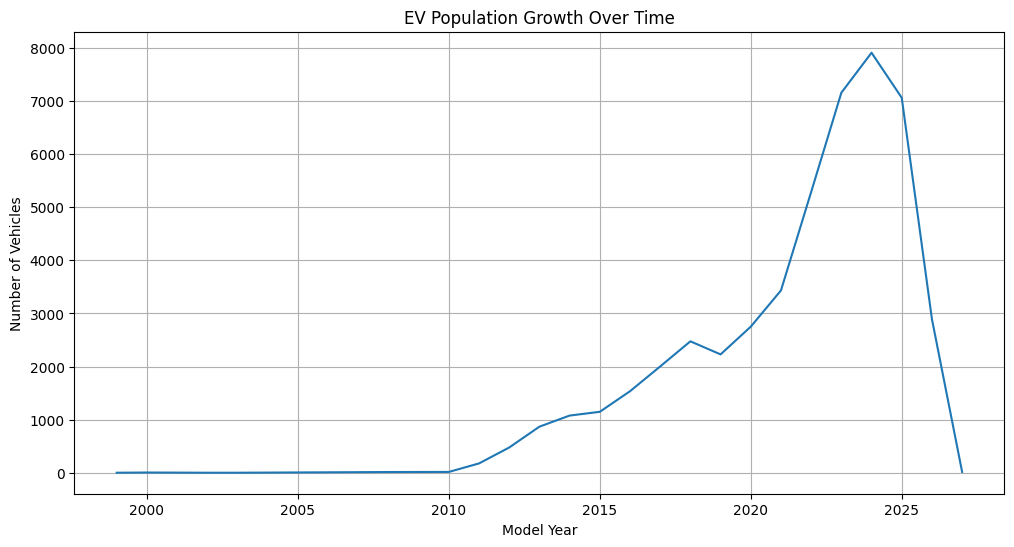

In [9]:
#1. EV population growth over time
import matplotlib.pyplot as plt
year_counts = cleaned_df["Model Year"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values)
plt.title("EV Population Growth Over Time") 
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.grid(True)
plt.show()


### Top EV Manufacturers

This chart shows that a few manufacturers control the EV market, with Tesla being on the top.

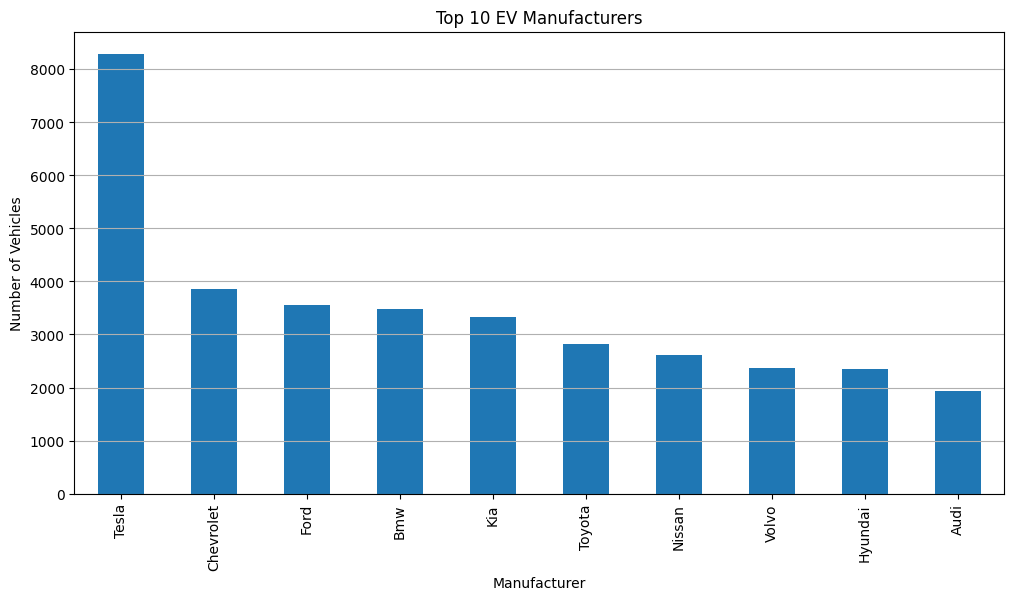

In [10]:
import matplotlib.pyplot as plt

make_counts = cleaned_df["Make"].value_counts().head(10)

plt.figure(figsize=(12,6))
make_counts.plot(kind="bar")

plt.title("Top 10 EV Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")
plt.grid(axis='y')
plt.show()

### EV Adoption by County

Urban counties show higher EV adoption and this might be becuase of hte devloped infrastructure and higher population.

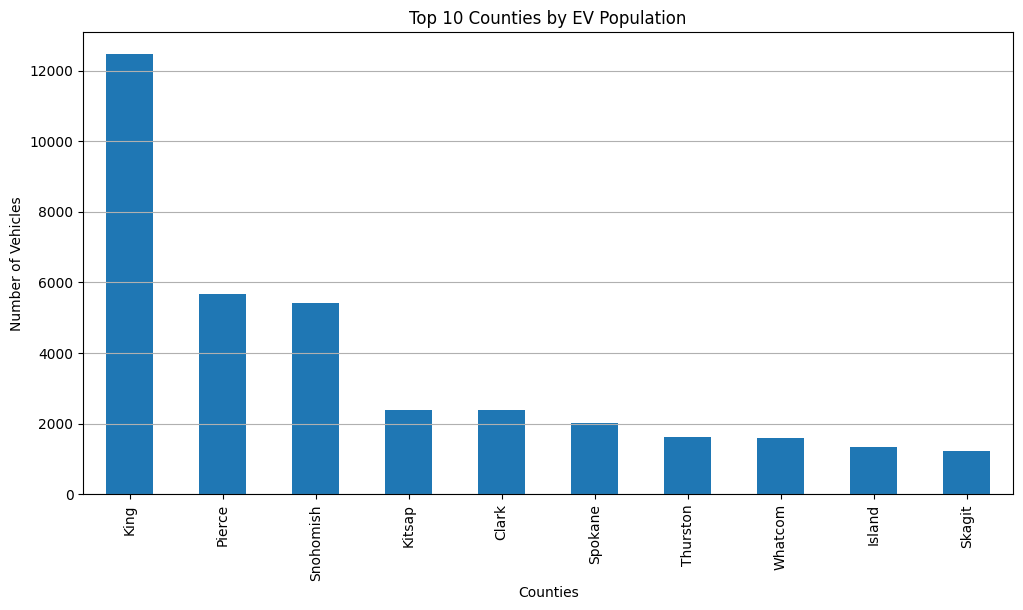

In [11]:
import matplotlib.pyplot as plt

county_counts = cleaned_df["County"].value_counts().head(10)
plt.figure(figsize=(12,6))
county_counts.plot(kind="bar")

plt.title("Top 10 Counties by EV Population")
plt.xlabel("Counties")
plt.ylabel("Number of Vehicles")
plt.grid(axis='y')
plt.show()

### Top 10 Manufacturers by Average Electric Range

Jaguar has the highest average electric range, followed by Tesla, Fiat, and Chevrolet. Tesla’s position near the top matchs with its reputation for making long-range electric vehicles.

However, some manufacturers may appear higher due to having fewer models or a smaller dataset, which can increase their average range. while, manufacturers like Nissan and Chevrolet produce a lot of different vehicles, including older or lower-range models, which reduces their overall average. Manufacturers like Nissan and Chevrolet create vehicles for many types of poeple and their invidiual needs.

This chart shows that while some brands specialize in higher-range vehicles, but market dominance and average performance are two different matters.

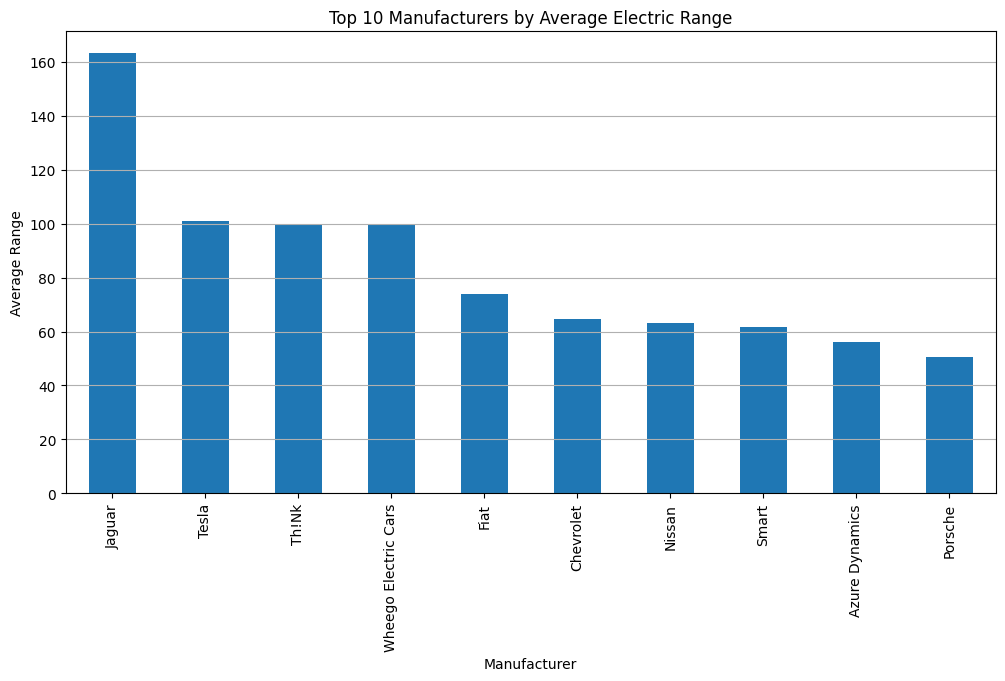

In [24]:
import matplotlib.pyplot as plt

avg_range = (
    cleaned_df.groupby("Make")["Electric Range"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

avg_range.plot(kind="bar")

plt.title("Top 10 Manufacturers by Average Electric Range")
plt.xlabel("Manufacturer")
plt.ylabel("Average Range")
plt.grid(axis='y')

plt.show()

## Machine Learning Model

A Linear Regression model is used to predict EV growth over time.

### Why Linear Regression?

- Easy to interpretable  
- Works well with trend-based data  
- Provides a good baseline prediction   

In [25]:
yearly = df["Model Year"].value_counts().sort_index().reset_index()
yearly.columns = ["Year", "EV_Count"]
print(yearly.head())

   Year  EV_Count
0  1999         2
1  2000         7
2  2002         1
3  2003         1
4  2008        19


In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = yearly[["Year"]]
y = yearly["EV_Count"]

model = LinearRegression()
model.fit(X, y)

future_years = pd.DataFrame({"Year": [2026, 2027, 2028, 2029, 2030]})
predictions = model.predict(future_years)

future_years["Predicted_EV_Count"] = predictions
print(future_years)

   Year  Predicted_EV_Count
0  2026        26402.006404
1  2027        27692.176946
2  2028        28982.347489
3  2029        30272.518032
4  2030        31562.688574


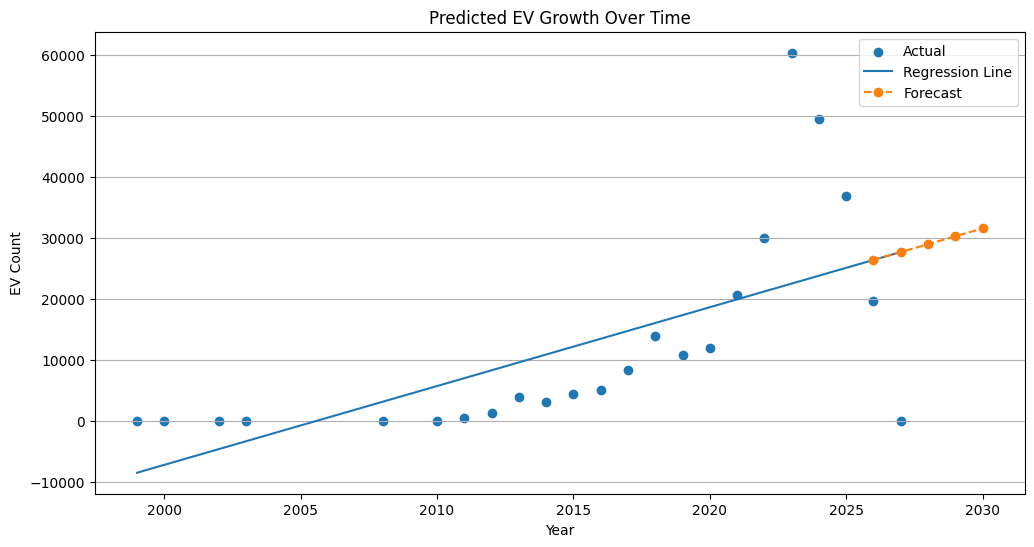

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual data
plt.scatter(yearly["Year"], yearly["EV_Count"], label="Actual")

# Regression line
plt.plot(yearly["Year"], model.predict(X), label="Regression Line")

plt.plot(
    future_years["Year"], 
    future_years["Predicted_EV_Count"], 
    linestyle="--", 
    marker="o", 
    label="Forecast"
)

plt.title("Predicted EV Growth Over Time")
plt.xlabel("Year")
plt.ylabel("EV Count")
plt.grid(axis='y')
plt.legend()

plt.show()

### Prediction Results

The model shows a clear upward trend in EV adoption, indicating continued growth in the future.

## Key Findings

- EV adoption has increased at a higher pace after 2018  
- Tesla controls most of the EV market  
- EV adoption is higher in urban regions  
- Battery EVs are more popular than hybrids

## Challenges and Limitations

- Missing values made the dataset smaller  
- Model Year and Registration year are not the same, people don't need to buy cars when it come out 
- Linear regression oversimplify future growth

### What Could Be Improved

- Use more advanced models such as Random Forest, Time Series  
- Include more data such as income, population, and policies

## Conclusion

This project shows strong growth in EV market and highlights key trends in manufacturers and regions. The Linear model suggests continued growth, although a better model can be used to improve model accuracy .